## Imports & Config

In [1]:
# !pip install -q spacy lexical-diversity accelerate
# !python -m spacy download en_core_web_sm
import nltk; nltk.download('stopwords', quiet=True); nltk.download('punkt', quiet=True)

True

In [2]:
!pip install -q lexical-diversity
import lexical_diversity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 5.0 MB/s eta 0:00:00


In [3]:
!pip install -q textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 18.1 MB/s eta 0:00:00


In [4]:
import textstat # Import textstat for readability metrics
from lexical_diversity import lex_div as ld

In [5]:
import torch.nn as nn
from sklearn.metrics import f1_score, precision_recall_fscore_support, accuracy_score
import numpy as np

In [6]:
# Standard library imports
import ast
import json
import os
import warnings
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
# Third-party library imports
import matplotlib.pyplot as plt
import networkx as nx
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import torch
from torch.utils.data import DataLoader
# Scikit-learn imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support, recall_score, silhouette_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

# Hugging Face Transformers imports
from transformers import (
    AutoModelForSequenceClassification, AutoModelForTokenClassification, AutoTokenizer,
    EarlyStoppingCallback, pipeline, RobertaConfig, Trainer, TrainingArguments
)

# Suppress warnings and set environment variables
warnings.filterwarnings('ignore')
os.environ['TOKENIZER_PARALLELISM'] = 'false'

# Configuration
MAX_LEN = 128
BATCH_SIZE = 16
SEED = 42
weights = torch.tensor([1.0, 3.0])

# Initialize NLP tools and tokenizer
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 5000000 # Increased to handle longer texts
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

print("Setup complete")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Setup complete


## Load & Preprocess Data

In [7]:
def load_jsonl_from_url(url):
    import urllib.request
    rows = []
    with urllib.request.urlopen(url) as f:
        for line in f:
            rows.append(json.loads(line.decode('utf-8').strip()))
    return pd.DataFrame(rows)

# VUAMC (labeled)
VUAMC_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/vuamc_token.jsonl"
df_vuamc = load_jsonl_from_url(VUAMC_URL)

print(f"VUAMC: {len(df_vuamc)} rows")

# Authors (unlabeled test data)
AUTHORS_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/authors_dataset.csv"
df_authors = pd.read_csv(AUTHORS_URL)
df_authors['words'] = df_authors['words'].apply(ast.literal_eval)
df_authors['token_labels'] = df_authors['words'].apply(lambda x: [0]*len(x))  # Placeholder
df_authors['sentence_label'] = 0
print(f"Authors: {len(df_authors)} rows")

# Load NarraDetect dataset
NARRA_DETECT_URL = "https://raw.githubusercontent.com/Dona134/Metaphor-Classification-NLP/main/data/processed/NarraDetect.csv"
df_narradetect_raw = pd.read_csv(NARRA_DETECT_URL)
df_narradetect_raw['words'] = df_narradetect_raw['words'].apply(ast.literal_eval)
df_narradetect_raw['token_labels'] = df_narradetect_raw['words'].apply(lambda x: [0]*len(x))  # Placeholder
df_narradetect_raw['sentence_label'] = 0 # Placeholder
print(f"NarraDetect: {len(df_narradetect_raw)} rows")

VUAMC: 16740 rows
Authors: 8000 rows
NarraDetect: 19126 rows


## VUAMC Splits

In [8]:
def make_doc_splits(df, test_size=0.5, val_size=0.5, seed=42):
    doc_ids = df['document_name'].unique()
    train_ids, temp_ids = train_test_split(doc_ids, test_size=test_size, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=val_size, random_state=seed)
    return (df[df['document_name'].isin(train_ids)].reset_index(drop=True),
            df[df['document_name'].isin(val_ids)].reset_index(drop=True),
            df[df['document_name'].isin(test_ids)].reset_index(drop=True))

# Use full data or stratified sample
df_vuamc = df_vuamc.groupby("sentence_label", group_keys=False).apply(
    lambda x: x.sample(min(5000, len(x)), random_state=SEED) # Added random_state
)

train_df, val_df, test_df = make_doc_splits(df_vuamc)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 4316, Val: 2765, Test: 2919


## Loading Models from Hugging Face Hub

In [9]:
# --- Load Sentence Classifier Model ---
sent_model_repo_id = "Dona134/metaphor-sentence-classifier"
sent_model = AutoModelForSequenceClassification.from_pretrained(sent_model_repo_id)
print(f"Sentence classifier loaded from {sent_model_repo_id}")

# --- Load Token Classifier Model ---
token_model_repo_id = "Dona134/metaphor-token-classifier"
token_model = AutoModelForTokenClassification.from_pretrained(token_model_repo_id)
print(f"Token classifier loaded from {token_model_repo_id}")

print("Models successfully loaded.")

config.json:   0%|          | 0.00/740 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Sentence classifier loaded from Dona134/metaphor-sentence-classifier


config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Token classifier loaded from Dona134/metaphor-token-classifier
Models successfully loaded.


In [10]:
# Initialize sentence classification pipeline with the loaded model and tokenizer
sent_pipe = pipeline('text-classification', model=sent_model, tokenizer=tokenizer, return_all_scores=True)
print("Sentence classification pipeline initialized using loaded models.")

Sentence classification pipeline initialized using loaded models.


##  Train Token Classifier (Best F1=0.692)

In [11]:
class TokenDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.words = [r['words'] for _,r in df.iterrows()]
        self.labels = [r['token_labels'] for _,r in df.iterrows()]
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.words)


    def __getitem__(self, idx):
        words = self.words[idx]
        labels = self.labels[idx]
    # Pad labels to max_len
        padded_labels = labels + [-100] * (self.max_len - len(labels))
        padded_labels = padded_labels[:self.max_len]  # Truncate if still too long


        # Tokenize with fixed padding
        encoding = self.tok(
            words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        # Align labels to tokens: only label the first subword of each original word
        word_ids = encoding.word_ids()
        aligned_labels = [-100] * self.max_len # Initialize all to -100
        previous_word_idx = None
        for i, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx < len(labels):
                # Only label the first token of a given word
                if word_idx != previous_word_idx:
                    aligned_labels[i] = labels[word_idx]
                previous_word_idx = word_idx

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(aligned_labels, dtype=torch.long)
        }


token_train = TokenDataset(train_df, tokenizer, max_len=MAX_LEN)
token_val = TokenDataset(val_df, tokenizer, max_len=MAX_LEN)
token_pipe = pipeline('token-classification', model=token_model, tokenizer=tokenizer, aggregation_strategy="simple")

print("TokenDataset class and token_pipe initialized using pre-loaded models.")
print("Training code for token classifier has been removed as per user request.")

TokenDataset class and token_pipe initialized using pre-loaded models.
Training code for token classifier has been removed as per user request.


In [12]:
class SentDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.sentences = [' '.join(r['words']) for _, r in df.iterrows()]
        self.labels = df['sentence_label'].values # Keep labels as an attribute

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        # Return only the text for the pipeline to process
        return self.sentences[idx]

print("SentDataset class defined for sentence classification pipeline.")

SentDataset class defined for sentence classification pipeline.


### Finding Optimal Sentence Threshold

In [13]:
from sklearn.metrics import f1_score
from transformers import pipeline, BatchEncoding

def evaluate_sent_threshold(sent_pipe, sent_dataset, threshold):
    # True labels are directly accessible from the dataset object's 'labels' attribute
    true_labels = sent_dataset.labels

    # The pipeline will directly iterate over the dataset and batch it.
    # It only needs the text from the dataset, which SentDataset.__getitem__ now provides.
    sent_pred_outputs = sent_pipe(sent_dataset, batch_size=32, truncation=True, max_length=MAX_LEN)

    predicted_labels = []
    for sent_pred_output in sent_pred_outputs:
        meta_prob = 0.0
        if isinstance(sent_pred_output, list):
            meta_prob = next((s['score'] for s in sent_pred_output if s['label'] == 'LABEL_1'), 0.0)
        elif isinstance(sent_pred_output, dict):
            if sent_pred_output['label'] == 'LABEL_1':
                meta_prob = sent_pred_output['score']
        predicted_labels.append(1 if meta_prob >= threshold else 0)

    return f1_score(true_labels, predicted_labels, average='binary', pos_label=1)

print("Function to evaluate sentence thresholds defined (now uses SentDataset).")

Function to evaluate sentence thresholds defined (now uses SentDataset).


Searching for optimal sentence threshold...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



Optimal Sentence Threshold (from val_df): 0.10
Best Sentence F1-score (from val_df): 0.838


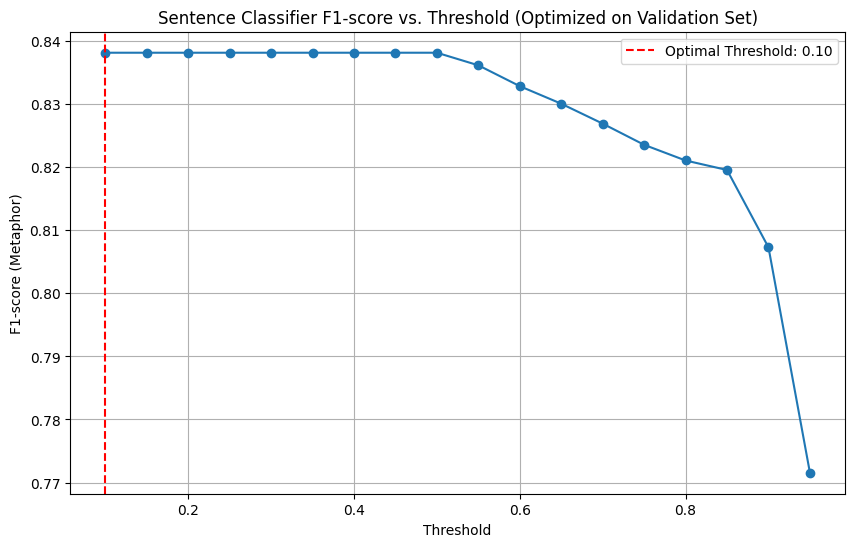

In [14]:
sent_thresholds = np.arange(0.1, 1.0, 0.05) # Test thresholds from 0.1 to 0.95
sent_f1_scores = []

# Create the SentDataset for the validation set
val_sent_dataset = SentDataset(val_df)

print("Searching for optimal sentence threshold...")
for t in sent_thresholds:
    # Use val_sent_dataset for threshold optimization to prevent data leakage
    f1 = evaluate_sent_threshold(sent_pipe, val_sent_dataset, t)
    sent_f1_scores.append(f1)

best_sent_threshold_idx = np.argmax(sent_f1_scores)
best_sent_threshold = sent_thresholds[best_sent_threshold_idx]
best_sent_f1 = sent_f1_scores[best_sent_threshold_idx]

print(f"\nOptimal Sentence Threshold (from val_df): {best_sent_threshold:.2f}")
print(f"Best Sentence F1-score (from val_df): {best_sent_f1:.3f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sent_thresholds, sent_f1_scores, marker='o')
plt.title('Sentence Classifier F1-score vs. Threshold (Optimized on Validation Set)')
plt.xlabel('Threshold')
plt.ylabel('F1-score (Metaphor)')
plt.grid(True)
plt.axvline(x=best_sent_threshold, color='r', linestyle='--', label=f'Optimal Threshold: {best_sent_threshold:.2f}')
plt.legend()
plt.show()

### Finding Optimal Token Threshold

In [15]:
def evaluate_token_threshold(token_logits, true_labels, threshold):
    token_logits = torch.as_tensor(token_logits, dtype=torch.float32)
    true_labels = np.array(true_labels)

    # Convert logits to probabilities over labels
    token_probs = torch.softmax(token_logits, dim=-1).cpu().numpy()

    # Probability for class 1 = METAPHOR
    metaphor_probs = token_probs[:, :, 1]

    # Apply threshold
    predicted_labels = (metaphor_probs >= threshold).astype(int)

    # Flatten while ignoring padded/subword positions marked as -100
    true_labels_flat = []
    predicted_labels_flat = []

    for label_row, pred_row in zip(true_labels, predicted_labels):
        for l, p in zip(label_row, pred_row):
            if l != -100:
                true_labels_flat.append(int(l))
                predicted_labels_flat.append(int(p))

    if len(true_labels_flat) == 0:
        return 0.0

    return f1_score(true_labels_flat, predicted_labels_flat, average='binary', pos_label=1)

val_token_logits shape: (2765, 128, 2)
val_token_true_labels shape: (2765, 128)
Searching for optimal token threshold...

Optimal Token Threshold (from val_df): 0.50
Best Token F1-score (from val_df): 0.716


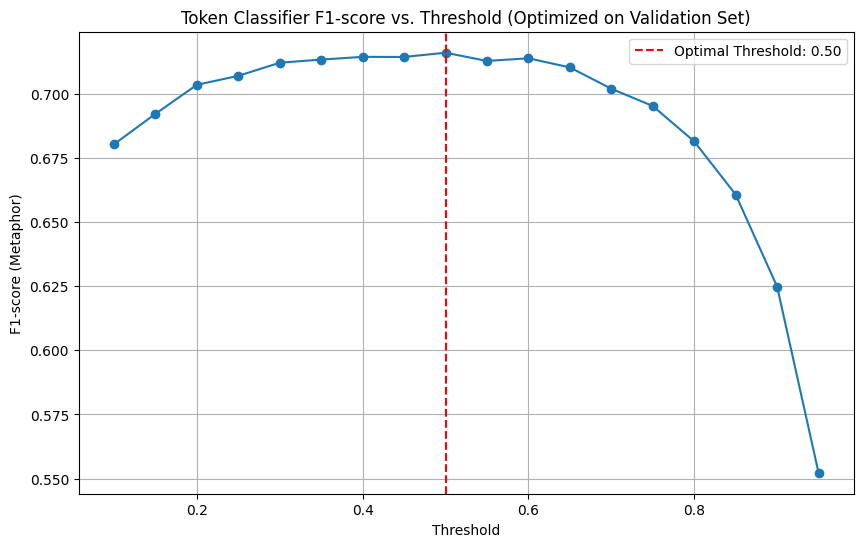

In [16]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
token_model.to(device)
token_model.eval()

# Build validation dataset
token_val = TokenDataset(val_df, tokenizer, max_len=MAX_LEN)
val_token_loader = DataLoader(token_val, batch_size=16, shuffle=False)

val_all_logits = []
val_all_labels = []

with torch.no_grad():
    for batch in val_token_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()

        outputs = token_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        val_all_logits.append(logits.cpu().numpy())
        val_all_labels.extend(labels)

val_token_logits = np.concatenate(val_all_logits, axis=0)
val_token_true_labels = np.array(val_all_labels)

print(f"val_token_logits shape: {val_token_logits.shape}")
print(f"val_token_true_labels shape: {val_token_true_labels.shape}")

# Now proceed with optimal token threshold search using val_token_logits and val_token_true_labels
token_thresholds = np.arange(0.1, 1.0, 0.05) # Test thresholds from 0.1 to 0.95
token_f1_scores = []

print("Searching for optimal token threshold...")
for t in token_thresholds:
    # Use val_token_logits and val_token_true_labels for threshold optimization
    f1 = evaluate_token_threshold(val_token_logits, val_token_true_labels, t)
    token_f1_scores.append(f1)

best_token_threshold_idx = np.argmax(token_f1_scores)
best_token_threshold = token_thresholds[best_token_threshold_idx]
best_token_f1 = token_f1_scores[best_token_threshold_idx]

print(f"\nOptimal Token Threshold (from val_df): {best_token_threshold:.2f}")
print(f"Best Token F1-score (from val_df): {best_token_f1:.3f}")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(token_thresholds, token_f1_scores, marker='o')
plt.title('Token Classifier F1-score vs. Threshold (Optimized on Validation Set)')
plt.xlabel('Threshold')
plt.ylabel('F1-score (Metaphor)')
plt.grid(True)
plt.axvline(x=best_token_threshold, color='r', linestyle='--', label=f'Optimal Threshold: {best_token_threshold:.2f}')
plt.legend()
plt.show()

### Error analysis

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
token_model.to(device)
token_model.eval()

# Redefine token_test here for error analysis
token_test = TokenDataset(test_df, tokenizer, max_len=MAX_LEN)
token_loader = DataLoader(token_test, batch_size=16, shuffle=False)

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in token_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].cpu().numpy()

        outputs = token_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=-1).cpu().numpy()

        all_predictions.append(preds)
        all_labels.append(labels)

token_predictions = np.concatenate(all_predictions, axis=0)
token_labels = np.concatenate(all_labels, axis=0)


In [18]:
def analyze_errors(dataset, predictions, true_labels, tokenizer):
    misclassified_examples = []

    for i in range(len(true_labels)):
        original_words = dataset.words[i]
        predicted_labels_row = predictions[i]
        true_labels_row = true_labels[i]

        encoding = tokenizer(
            original_words,
            is_split_into_words=True,
            truncation=True,
            padding='max_length',
            max_length=dataset.max_len,
            return_tensors='pt'
        )

        word_ids = encoding.word_ids(batch_index=0)
        input_ids = encoding["input_ids"][0].tolist()

        previous_word_id = None

        for j, word_id in enumerate(word_ids):
            if word_id is None:
                continue

            if true_labels_row[j] == -100:
                continue

            is_first_subword = (word_id != previous_word_id)
            previous_word_id = word_id

            if true_labels_row[j] != predicted_labels_row[j]:
                token = tokenizer.convert_ids_to_tokens(input_ids[j])

                misclassified_examples.append({
                    "document_idx": i,
                    "token_idx_in_sentence": j,
                    "token": token,
                    "true_label": int(true_labels_row[j]),
                    "predicted_label": int(predicted_labels_row[j]),
                    "full_sentence_words": original_words,
                    "word_id_in_original_sentence": int(word_id),
                    "is_first_subword": is_first_subword
                })

    # Return all misclassified examples for full analysis
    return misclassified_examples

In [19]:
misclassified_tokens = analyze_errors(token_test, token_predictions, token_labels, tokenizer)
print(f"Found {len(misclassified_tokens)} misclassified tokens.")

if misclassified_tokens:
    false_positives = [e for e in misclassified_tokens if e["true_label"] == 0 and e["predicted_label"] == 1]
    false_negatives = [e for e in misclassified_tokens if e["true_label"] == 1 and e["predicted_label"] == 0]

    print("\n--- Example False Positives (True: LITERAL, Predicted: METAPHOR) ---")
    for i, error in enumerate(false_positives[:10]): # Display up to 10 false positives
        print(f"--- Error {i+1} ---")
        print(f"Document Index: {error['document_idx']}")
        print(f"Token: {error['token']}")
        print(f"True Label: {error['true_label']}, Predicted Label: {error['predicted_label']}")
        print(f"Original Word Index: {error['word_id_in_original_sentence']}, Is First Subword: {error['is_first_subword']}")
        print(f"Sentence: {' '.join(error['full_sentence_words'])}")

    print("\n--- Example False Negatives (True: METAPHOR, Predicted: LITERAL) ---")
    for i, error in enumerate(false_negatives[:10]): # Display up to 10 false negatives
        print(f"--- Error {i+1} ---")
        print(f"Document Index: {error['document_idx']}")
        print(f"Token: {error['token']}")
        print(f"True Label: {error['true_label']}, Predicted Label: {error['predicted_label']}")
        print(f"Original Word Index: {error['word_id_in_original_sentence']}, Is First Subword: {error['is_first_subword']}")
        print(f"Sentence: {' '.join(error['full_sentence_words'])}")

Found 3005 misclassified tokens.

--- Example False Positives (True: LITERAL, Predicted: METAPHOR) ---
--- Error 1 ---
Document Index: 0
Token: this
True Label: 0, Predicted Label: 1
Original Word Index: 3, Is First Subword: True
Sentence: Fifteen quid for this .
--- Error 2 ---
Document Index: 4
Token: sw
True Label: 0, Predicted Label: 1
Original Word Index: 4, Is First Subword: True
Sentence: ‘ She was all swollen . ’
--- Error 3 ---
Document Index: 17
Token: in
True Label: 0, Predicted Label: 1
Original Word Index: 1, Is First Subword: True
Sentence: Three in two .
--- Error 4 ---
Document Index: 22
Token: van
True Label: 0, Predicted Label: 1
Original Word Index: 8, Is First Subword: True
Sentence: Beryl Verne-Smith peered , but the picture immediately vanished .
--- Error 5 ---
Document Index: 40
Token: get
True Label: 0, Predicted Label: 1
Original Word Index: 3, Is First Subword: True
Sentence: He had to get rid of it .
--- Error 6 ---
Document Index: 40
Token: rid
True Label: 

## Stylistic Features

In [97]:
english_stopwords = set(nltk.corpus.stopwords.words('english'))
def compute_enriched_features(doc_df, pipeline_meta_tokens, token_threshold=0.5):
    all_words = [w for sublist in doc_df['words'] for w in sublist]
    full_text = ' '.join(all_words)
    doc = nlp(full_text)

    # Calculate total subword tokens using the HuggingFace tokenizer
    # This aligns the denominator with how pipeline_meta_tokens are counted
    encoded_input = tokenizer(all_words, is_split_into_words=True, add_special_tokens=False)
    total_subword_tokens = len(encoded_input['input_ids'])

    # Use the passed token_threshold for metaphor density calculation
    num_meta = len(pipeline_meta_tokens)
    mtld_score = ld.mtld(all_words)

    # Process sentences based on doc_df rows (as each row is a sentence)
    num_sents = len(doc_df) # Each row in doc_df represents a sentence
    sent_lengths = [len(words_list) for words_list in doc_df['words']] # Length of words in each sentence row

    # Calculate POS counts and total tokens for robustness
    num_nouns = sum(1 for t in doc if t.pos_ == 'NOUN')
    num_verbs = sum(1 for t in doc if t.pos_ == 'VERB')
    num_adj = sum(1 for t in doc if t.pos_ == 'ADJ')
    num_adv = sum(1 for t in doc if t.pos_ == 'ADV')
    num_content_words = num_nouns + num_verbs + num_adj + num_adv
    num_function_words = sum(1 for t in doc if t.is_stop or t.pos_ in ['ADP', 'PRT', 'CONJ'])
    num_ccomp_clauses = len([t for t in doc if t.dep_ == 'ccomp'])
    total_tokens_doc = len(doc)

    return {
        # Metaphor Core
        'meta_density': num_meta / total_subword_tokens if total_subword_tokens else 0, # Changed denominator

        # Lexical (2)
        'mtld': mtld_score,

        # Syntactic (3)
        'avg_sent_len': np.mean(sent_lengths) if num_sents > 0 else 0,
        'sent_len_var': np.var(sent_lengths) if num_sents > 0 else 0,
       # 'passive_ratio': num_passive_clauses / max(1, num_finite_clauses),

        # Semantic (2)
        'noun_verb_ratio': num_nouns / max(1, num_verbs), # Ensure no division by zero
        'content_density': num_content_words / total_tokens_doc if total_tokens_doc else 0,

        # Readability (2)
        #'flesch_kincaid_grade': flesch_kincaid_grade
    }

In [98]:
def pipeline_on_test_df(df_input, sent_pipe, token_pipe, batch_size=32, sent_threshold=best_sent_threshold, token_threshold=best_token_threshold):
    test_results = {}

    df = df_input.reset_index(drop=True)

    # Sentence predictions
    all_sentences = [' '.join(row['words']) for _, row in df.iterrows()]
    sent_preds_batch = sent_pipe(all_sentences, batch_size=batch_size, truncation=True, max_length=MAX_LEN)

    metaphorical_sentences = []
    original_sent_indices = [] # Store list index for mapping back
    for i, sent_pred_output in enumerate(sent_preds_batch):
        meta_prob = 0.0
        if isinstance(sent_pred_output, list):
            # Expected behavior with return_all_scores=True
            meta_prob = next((s['score'] for s in sent_pred_output if s['label'] == 'LABEL_1'), 0.0)
        elif isinstance(sent_pred_output, dict):
            # Fallback if return_all_scores=False was implicitly used (single top prediction)
            if sent_pred_output['label'] == 'LABEL_1':
                meta_prob = sent_pred_output['score']

        if meta_prob > sent_threshold:
            metaphorical_sentences.append(all_sentences[i])
            original_sent_indices.append(i) # Store list index 'i'

    # Token predictions on metaphorical sentences only
    meta_token_preds = []
    if metaphorical_sentences:
       meta_token_preds = token_pipe(metaphorical_sentences, batch_size=batch_size)

    # Initialize a list of lists for all sentences to store their token predictions
    all_sentence_token_preds = [[] for _ in range(len(all_sentences))]

    # Map token predictions back to original sentence list indices
    for filtered_idx, original_list_idx in enumerate(original_sent_indices):
        if filtered_idx < len(meta_token_preds):
            all_sentence_token_preds[original_list_idx] = meta_token_preds[filtered_idx]

    # Aggregate token predictions by document
    # The input `df` contains 'words' for each sentence.
    # We iterate through the processed dataframe to get document groups and their sentences.
    for doc_name, doc_group in df.groupby('document_name'):
        doc_meta_tokens = []
        for list_idx, row_in_doc_group in doc_group.iterrows(): # list_idx will now be the correct 0-based index
            # Pass token_threshold here
            doc_meta_tokens.extend([p for p in all_sentence_token_preds[list_idx] if p['score'] > token_threshold])
        test_results[doc_name] = doc_meta_tokens

    print(f"Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.")
    return test_results

print("Pipeline ready")

Pipeline ready


In [99]:
def build_stylistic_df(results, df, token_threshold=0.5):
    """
    Builds a DataFrame of stylistic features for documents.
    """
    doc_features = []
    for doc_name, meta_tokens in results.items(): # results already contains thresholded tokens from pipeline_on_test_df
        doc_group = df[df['document_name'] == doc_name]
        # Pass the token_threshold to compute_enriched_features
        features = compute_enriched_features(doc_group, meta_tokens, token_threshold=token_threshold)
        features['document_name'] = doc_name
        doc_features.append(features)
    return pd.DataFrame(doc_features)

## Run Pipeline on VUAMC Test

In [100]:
# Use optimal thresholds for final evaluation on test_df
test_results = pipeline_on_test_df(test_df, sent_pipe, token_pipe, sent_threshold=best_sent_threshold, token_threshold=best_token_threshold)
print(f"VUAMC test processed: {len(test_results)} documents")

KeyboardInterrupt: 

In [ ]:
pd.set_option('display.max_colwidth', None)
# random 20
test_df.sample(20)

In [ ]:
test_df.shape

In [ ]:
df_document_features = build_stylistic_df(test_results, test_df, token_threshold=best_token_threshold)
print(f"Computed features for {len(df_document_features)} documents.")
print(df_document_features.head())

In [ ]:
# plot correlation matrix
corr_matrix = df_document_features.drop(columns=['document_name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stylistic Features')
plt.show()

In [ ]:
# Prepare data for clustering: Drop 'document_name' and highly correlated 'sent_len_var'
vuamc_features_df = df_document_features.drop(columns=['document_name',  'flesch_kincaid_grade'])

scaler_vuamc = StandardScaler()
scaled_vuamc_features = scaler_vuamc.fit_transform(vuamc_features_df)

print("VUAMC test features scaled and ready for clustering.")

### Hierarchical Clustering for VUAMC Test Documents

In [ ]:
# Hierarchical Clustering for VUAMC test documents
hierarchical_vuamc = AgglomerativeClustering(n_clusters=3) # Starting with 3 clusters, can be adjusted
hierarchical_vuamc_labels = hierarchical_vuamc.fit_predict(scaled_vuamc_features)
df_document_features['hierarchical_cluster'] = hierarchical_vuamc_labels

# Create full_label for dendrogram
df_document_features['full_label'] = df_document_features['document_name']

# Evaluate Hierarchical Clustering
vuamc_hierarchical_silhouette = silhouette_score(scaled_vuamc_features, hierarchical_vuamc_labels)
print(f"VUAMC Hierarchical Silhouette Score (k=3): {vuamc_hierarchical_silhouette:.3f}")

print("Hierarchical clustering for VUAMC test documents complete.")

### Finding Optimal K for VUAMC Clustering using Silhouette Score

To determine the optimal number of clusters (k) for the VUAMC dataset, we will calculate the Silhouette Score for a range of `k` values. A higher Silhouette Score indicates better-defined clusters.

In [ ]:
silhouette_scores_vuamc = []
k_range_vuamc = range(2, 10) # Test k from 2 up to the number of data points - 1 to ensure enough samples per cluster

for k in k_range_vuamc:
    # Ensure k is valid for the number of samples
    if k < 2 or k >= len(scaled_vuamc_features):
        continue

    hierarchical_temp = AgglomerativeClustering(n_clusters=k)
    labels_temp = hierarchical_temp.fit_predict(scaled_vuamc_features)
    score = silhouette_score(scaled_vuamc_features, labels_temp)
    silhouette_scores_vuamc.append(score)

# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(list(k_range_vuamc), silhouette_scores_vuamc, marker='o')
plt.title('Silhouette Score for VUAMC Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_vuamc))
plt.grid(True)
plt.show()

optimal_k_vuamc = k_range_vuamc[np.argmax(silhouette_scores_vuamc)]
print(f"Optimal k for VUAMC dataset: {optimal_k_vuamc} (Silhouette Score: {max(silhouette_scores_vuamc):.3f})")

In [ ]:
plt.figure(figsize=(20, 10))
linked_vuamc = linkage(scaled_vuamc_features, method='ward')
dendrogram(linked_vuamc,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           labels=df_document_features['full_label'].tolist())
plt.title('Dendrogram for VUAMC Test Documents Hierarchical Clustering')
plt.xlabel('Document Name')
plt.ylabel('Distance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("The dendrogram visualizes the hierarchical clustering for the VUAMC test documents.")

### Documents per Hierarchical Cluster (VUAMC Test)

In [ ]:
vuamc_cluster_composition = df_document_features.groupby('hierarchical_cluster')['document_name'].apply(list).reset_index()
vuamc_cluster_composition.columns = ['Hierarchical Cluster', 'Document Names']
print(vuamc_cluster_composition.to_string())
print("This table shows which VUAMC test documents are assigned to each hierarchical cluster.")

# Run Pipeline on Authors Dataset

In [101]:
authors_results = pipeline_on_test_df(df_authors, sent_pipe, token_pipe, sent_threshold=best_sent_threshold, token_threshold=best_token_threshold)
print(f"Authors processed: {len(authors_results)} documents")

Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.
Authors processed: 80 documents


In [102]:
pd.set_option('display.max_colwidth', None)
# random 20
df_authors.sample(20)

,document_name,author,words,token_labels,sentence_label
4566,The Iron Heel,Jack London,"[Asmunsen, cried, and, many, voices, backed, his, decision]","[0, 0, 0, 0, 0, 0, 0, 0]",0
848,The Lost World,Arthur Conan Doyle,"[The, first, page, was, disappointing, however, as, it, contained, nothing, but, the, picture, of, a, very, fat, man, in, a, pea, jacket, with, the, legend, Jimmy, Colver, on, the, Mail, boat, written, beneath, it]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
4905,The Little Lady of the Big House,Jack London,"[Forrest, is, in, love, with, you, and, you, run, away, together, in, the, big, limousine, Oh, but, I, wouldn't, the, boy, blurted, out, his, cheeks, burning]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
1151,Caesar and Cleopatra,Bernard Shaw,"[Forbear, her, yet, a, moment, Persian]","[0, 0, 0, 0, 0, 0]",0
1194,Cashel Byron’s Profession,Bernard Shaw,"[Then, he, stopped, and, burst, into, tears]","[0, 0, 0, 0, 0, 0, 0]",0
957,The Memoirs of Sherlock Holmes,Arthur Conan Doyle,"[But, what, end]","[0, 0, 0]",0
5479,"The Poems of Jonathan Swift, D.D., Volume 1",Jonathan Swift,"[may, some, western, tempest, sweep, These, locusts, whom, our, fruits, have, fed, That, plague, directors, to, the, deep, Driven, from, the, South, Sea, to, the, Red]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
1009,Caesar and Cleopatra,Bernard Shaw,"[I, will, sacrifice, I, will, pay]","[0, 0, 0, 0, 0, 0]",0
6170,The Kingdom of God Is Within You,Leo Tolstoy,"[To, refute, such, an, assertion, is, useless, because, the, very, people, who, make, this, assertion, refute, themselves, or, rather, renounce, Christ, inventing, a, Christianity, and, a, Christ, of, their, own, in, the, place, of, him, in, whose, name, the, Church, itself, exists, as, well, as, their, office, in, it]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
6426,Anna Karenina,Leo Tolstoy,"[The, priest, got, him, out, of, his, difficulty]","[0, 0, 0, 0, 0, 0, 0, 0]",0


## Build stylistic df

In [103]:
authors_stylistics = build_stylistic_df(authors_results, df_authors, token_threshold=best_token_threshold)

In [104]:
authors_stylistics.head()

,meta_density,mtld,avg_sent_len,sent_len_var,noun_verb_ratio,content_density,document_name
0,0.167560,159.895041,17.430000,178.365100,1.221774,0.420539,A Study in Scarlet
1,0.176405,133.394449,20.740000,257.112400,1.812766,0.438284,An Unsocial Socialist
2,0.176890,108.856260,24.245098,235.753652,1.054795,0.424990,Anna Karenina
3,0.191046,133.525992,19.715686,87.144656,1.930328,0.471400,Burning Daylight
4,0.142755,122.609107,9.790000,91.385900,1.484375,0.398785,Caesar and Cleopatra


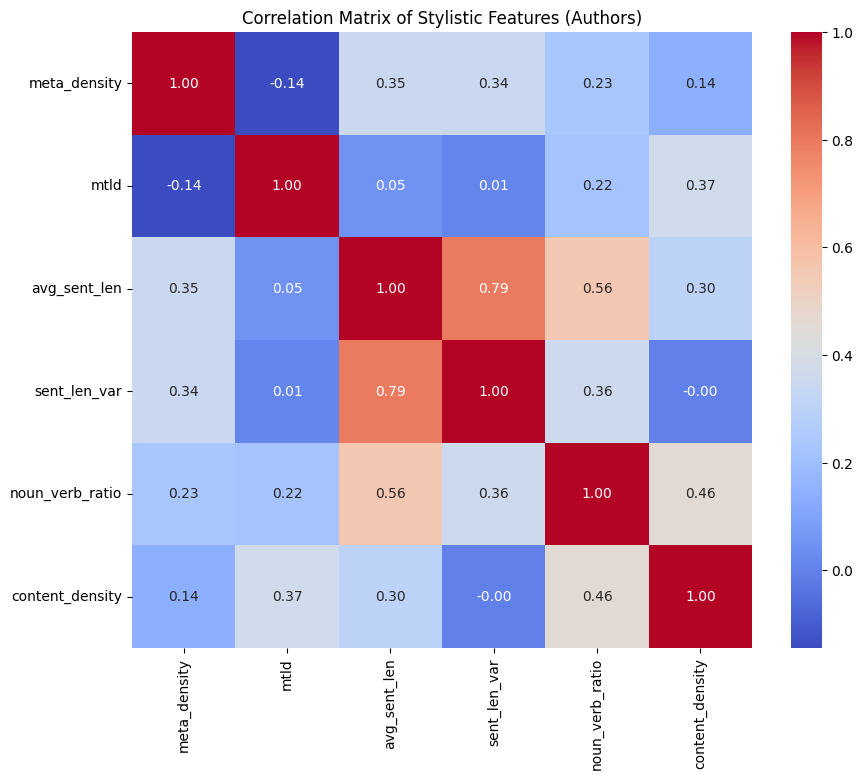

In [105]:
# plot correlation matrix
# Exclude 'document_name' column as it is not numeric for correlation calculation
corr_matrix = authors_stylistics.drop(columns=['document_name']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stylistic Features (Authors)')
plt.show()

## Clustering

In [107]:
# Prepare data for clustering: Drop 'document_name' and highly correlated 'sent_len_var'
features_df = authors_stylistics.drop(columns=['document_name', 'avg_sent_len'])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

print("Features scaled and ready for clustering.")

Features scaled and ready for clustering.


### Dendrogram for Hierarchical Clustering

In [108]:
# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3) # Using 3 clusters for comparison
hierarchical_labels = hierarchical.fit_predict(scaled_features)
authors_stylistics['hierarchical_cluster'] = hierarchical_labels

# Get unique document_name and author mapping from test_df
author_map = df_authors[['document_name', 'author']].drop_duplicates()

# Create authors_stylistics_with_author after clustering, ensuring it has hierarchical_cluster
authors_stylistics_with_author = authors_stylistics.merge(author_map, on='document_name', how='left')
authors_stylistics_with_author['full_label'] = authors_stylistics_with_author['document_name'] + ' (' + authors_stylistics_with_author['author'] + ')'

# Evaluate Hierarchical Clustering
hierarchical_silhouette = silhouette_score(scaled_features, hierarchical_labels)
print(f"Hierarchical Silhouette Score (k=3): {hierarchical_silhouette:.3f}")

print("Hierarchical clustering complete.")

Hierarchical Silhouette Score (k=3): 0.215
Hierarchical clustering complete.


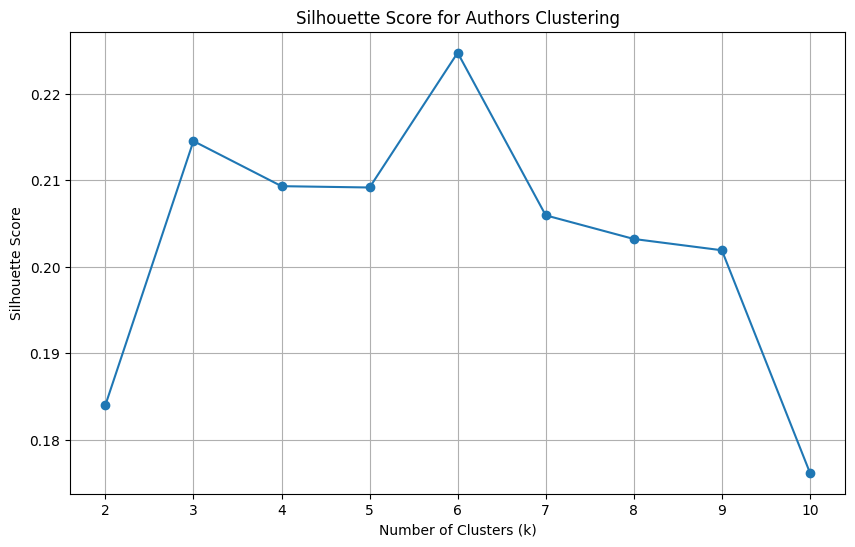

Optimal k for Authors dataset: 6 (Silhouette Score: 0.225)


In [109]:
silhouette_scores_authors = []
k_range_authors = range(2, 11) # Test k from 2 to 10

for k in k_range_authors:
    hierarchical_temp = AgglomerativeClustering(n_clusters=k)
    labels_temp = hierarchical_temp.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels_temp)
    silhouette_scores_authors.append(score)

# Plotting the Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_authors, silhouette_scores_authors, marker='o')
plt.title('Silhouette Score for Authors Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_authors))
plt.grid(True)
plt.show()

optimal_k_authors = k_range_authors[np.argmax(silhouette_scores_authors)]
print(f"Optimal k for Authors dataset: {optimal_k_authors} (Silhouette Score: {max(silhouette_scores_authors):.3f})")

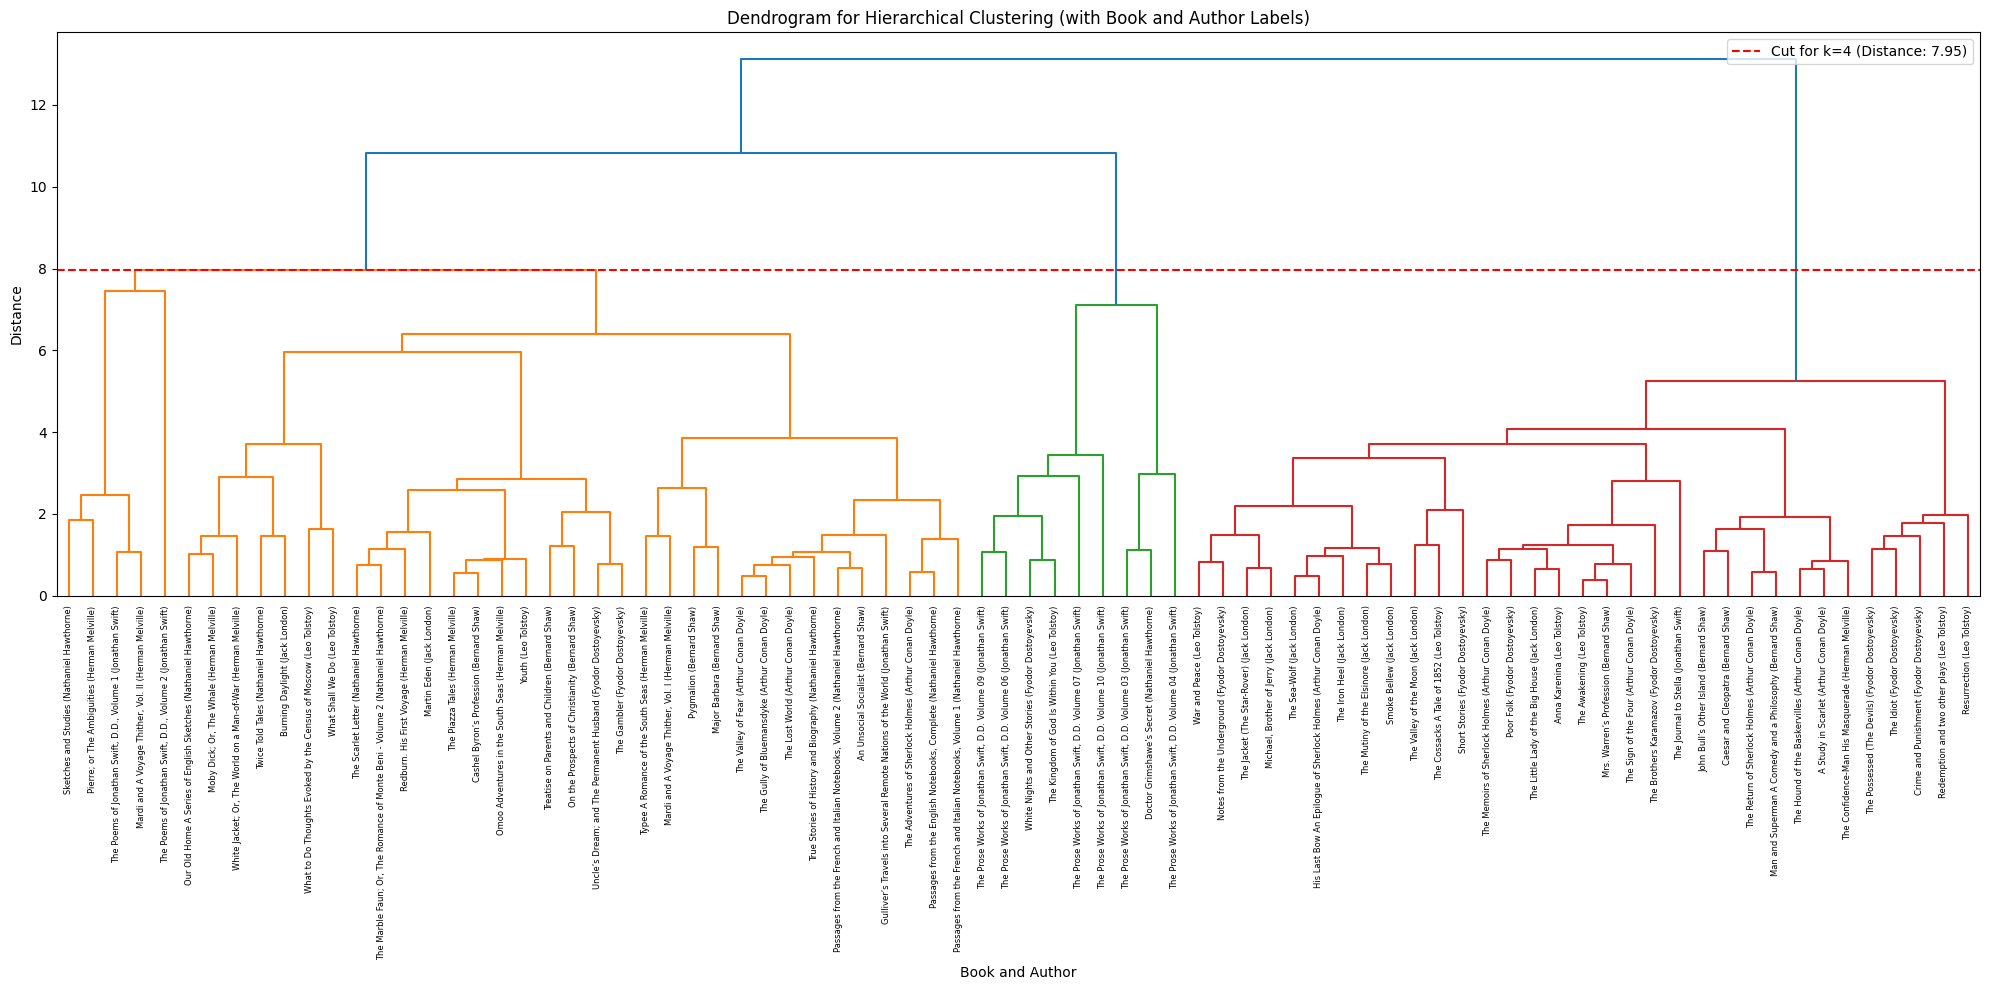

The dendrogram now visually represents the hierarchical clustering process with book and author names as labels. You can identify clusters by drawing a horizontal line across the dendrogram at a chosen distance, and the vertical lines it crosses represent the clusters.


In [110]:
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of labels
linked = linkage(scaled_features, method='ward') # 'ward' minimizes the variance of the clusters being merged
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False, # Set to False to prevent overlapping with custom labels
           labels=authors_stylistics_with_author['full_label'].tolist())
plt.title('Dendrogram for Hierarchical Clustering (with Book and Author Labels)')
plt.xlabel('Book and Author')
plt.ylabel('Distance')
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Add horizontal line for k=4 clusters
k_3_cut_height = linked[len(linked) - 3, 2]
plt.axhline(y=k_3_cut_height, color='r', linestyle='--', label=f'Cut for k=4 (Distance: {k_3_cut_height:.2f})')
plt.legend()

plt.show()

print("The dendrogram now visually represents the hierarchical clustering process with book and author names as labels. You can identify clusters by drawing a horizontal line across the dendrogram at a chosen distance, and the vertical lines it crosses represent the clusters.")

### Books per Hierarchical Cluster

In [111]:
cluster_author_composition = authors_stylistics_with_author.groupby(['hierarchical_cluster', 'author']).size().unstack(fill_value=0)
display(cluster_author_composition)
print("This table shows how many books from each author are assigned to each hierarchical cluster.")

author,Arthur Conan Doyle,Bernard Shaw,Fyodor Dostoyevsky,Herman Melville,Jack London,Jonathan Swift,Leo Tolstoy,Nathaniel Hawthorne
hierarchical_cluster,,,,,,,,
0,4,6,2,9,2,3,3,9
1,6,4,7,1,8,1,6,0
2,0,0,1,0,0,6,1,1


This table shows how many books from each author are assigned to each hierarchical cluster.


### Books in each Cluster

In [112]:
cluster_books = authors_stylistics_with_author.groupby('hierarchical_cluster')['full_label'].apply(list).reset_index()
cluster_books.columns = ['Hierarchical Cluster', 'Books (with Authors)']
print(cluster_books.to_string())
print("This table lists all books and their authors within each hierarchical cluster.")

   Hierarchical Cluster                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

### Book Similarity Heatmap

This heatmap visualizes the pairwise stylistic similarity between individual books. In our case, the vectors represent the stylistic features of the books. A cosine similarity close to 1 means the vectors are very similar (small angle between them), indicating the books have similar stylistic profiles. A value close to 0 (or even negative if the vectors are opposing) indicates dissimilarity.

## Cosine similarity heatmap

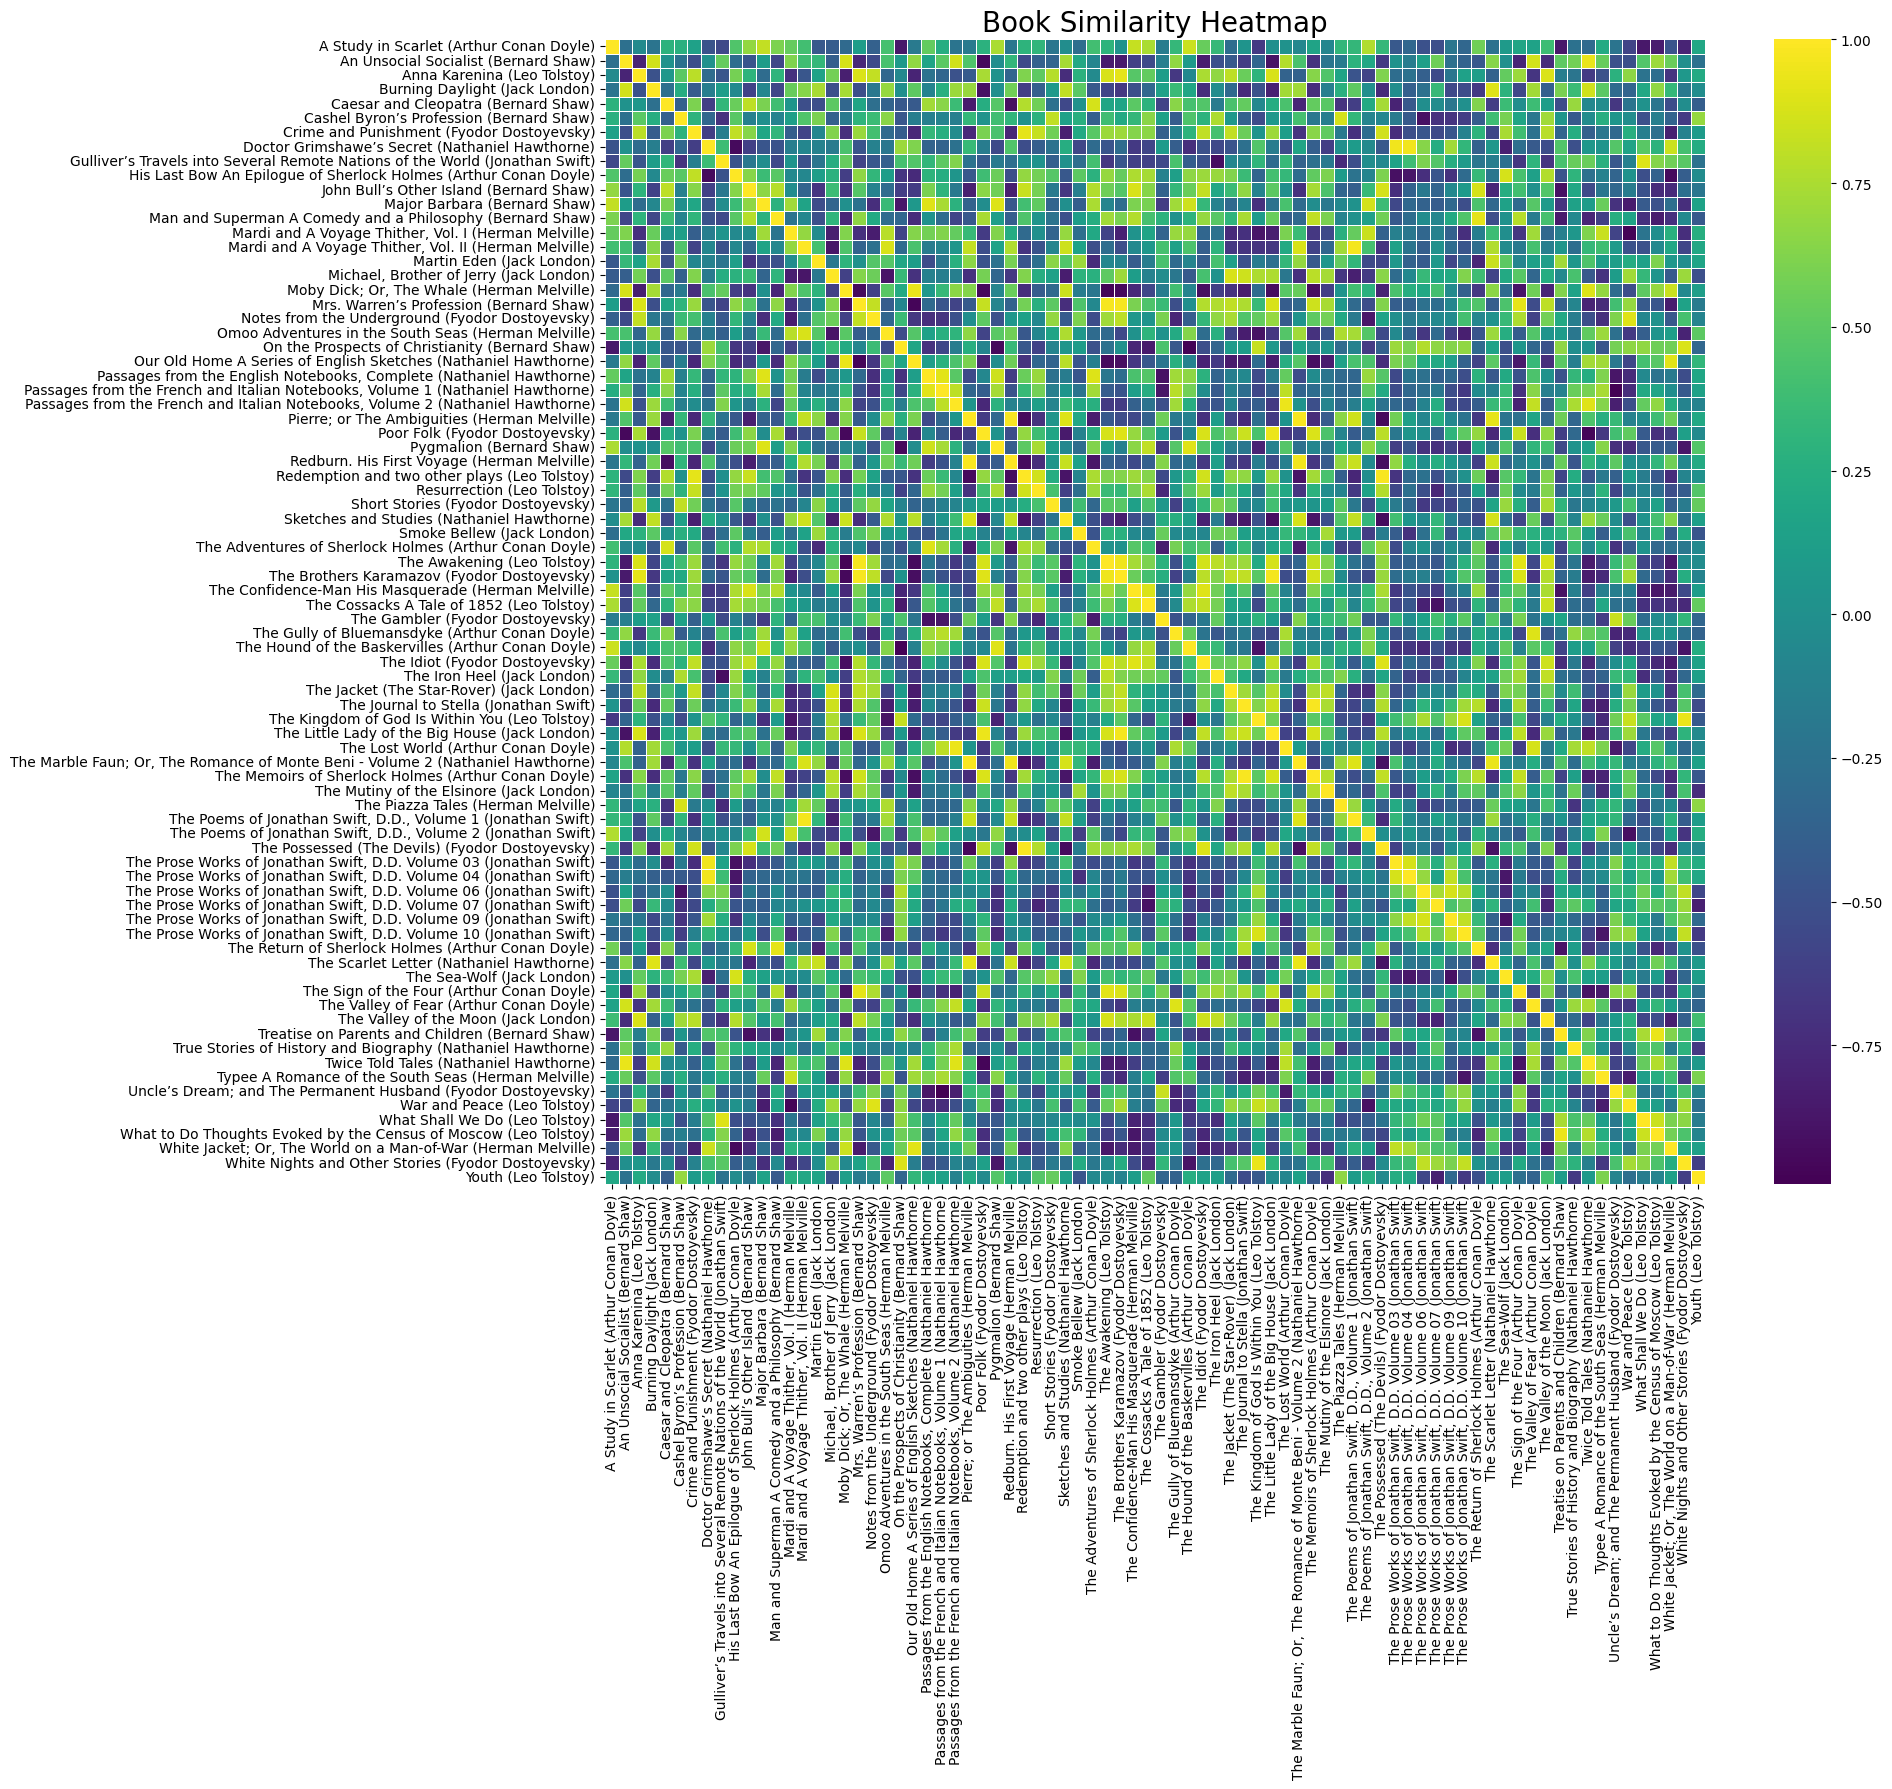

The heatmap above visualizes the pairwise stylistic similarity between books. Darker colors indicate higher similarity.


In [113]:
# Calculate cosine similarity between books
similarity_matrix_books = cosine_similarity(scaled_features)


# Add nodes for each book
book_labels = authors_stylistics_with_author['full_label'].tolist()
# Convert the similarity matrix to a DataFrame for better labeling
similarity_df_books = pd.DataFrame(similarity_matrix_books, index=book_labels, columns=book_labels)

plt.figure(figsize=(20, 18)) # Adjust figure size for readability
sns.heatmap(similarity_df_books,
            annot=False, # Set to True to show similarity values on the heatmap
            cmap='viridis', # Choose a colormap
            fmt=".2f", # Format annotation values
            linewidths=.5) # Add lines between cells
plt.title('Book Similarity Heatmap', size=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("The heatmap above visualizes the pairwise stylistic similarity between books. Darker colors indicate higher similarity.")

### Feature Importance for Hierarchical Clustering

To identify which stylistic features are most influential in forming the hierarchical clusters, we can train a classifier using the scaled features to predict the assigned cluster labels. The feature importances from this classifier can then highlight the distinguishing characteristics of the clusters.

,feature,importance
0,noun_verb_ratio,0.334667
1,content_density,0.266831
2,sent_len_var,0.222816
3,mtld,0.090977
4,meta_density,0.084708


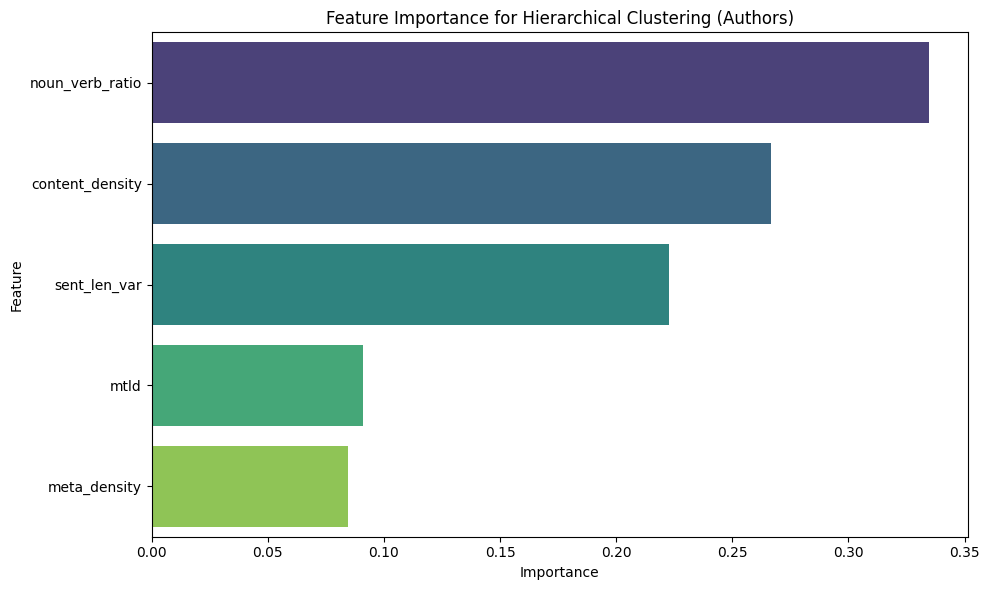

Feature importance analysis complete. The plot and table above show which features were most influential in determining the hierarchical clusters.


In [114]:
# Prepare data for feature importance analysis
X = scaled_features # Already scaled features from authors_stylistics
y = hierarchical_labels # Hierarchical cluster labels

# Train a RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model.fit(X, y)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Map importances to feature names
feature_names = features_df.columns # Get feature names from the original (non-dropped) features_df
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

display(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Feature Importance for Hierarchical Clustering (Authors)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance analysis complete. The plot and table above show which features were most influential in determining the hierarchical clusters.")

# Run on Narra_Detect

In [115]:
pd.set_option('display.max_colwidth', None)
# random 20
df_narradetect_raw.sample(20)

,document_name,id,words,token_labels,sentence_label
15863,REDDIT,c3c5xcbf7ql1,"[She, walks, out, to, front, room, and, sees, the, door, hanging, open, but, no, kids, to, be, found]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
13640,NOVEL19C,p1b069o2brk2,"[It, is, no, part, of, ours, to, describe, what, was, a, massacre, rather, than, a, fight]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
17525,SCOTUS,x8pzr90z0538,"[S, at, Frankfurter, J, concurring]","[0, 0, 0, 0, 0]",0
10512,LEGAL,betf46vz73an,"[Todos, shall, provide, the, Reseller, at, no, charge, with, initial, training, relating, to, the, efficient, use, and, operation, of, the, Products, as, well, as, instruction, regarding, use, of, all, associated, equipment, required, to, effectively, carry, out, the, TM, B, and, TM, B, cancer, screening, tests]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
13909,PHIL,ullt247pqa7b,"[concerning, the, general, principles, of, morals, and, though, we, postponed, the, decision, of, that, question, lest, it, should, then, involve, us, in, intricate, speculations, which, are, unfit, for, moral, discourses, we, may, resume, it, at, present, and, examine, how, far, either, REASON, or, SENTIMENT, enters, into, all, decisions, of, praise, or, censure]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
1382,ABSTRACT,meyj6rny7sje,"[By, mobilizing, the, socio, technical, approach, to, innovation, and, semi, directive, survey, of, stakeholders, this, paper, analyzes, the, value, chains, that, ensure, the, valorization, of, apricot, pit, by, products, and, the, dynamics, of, their, actors]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
657,LITSTUDY,yeuqq5iw0zj9,"[Sounds, made, harmonies, with, premeditation, the, spaces, between, them, were, as, significant, as, the, sounds]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
16282,ROC,c20n3c3gbfsa,"[He, was, having, a, good, time, at, first]","[0, 0, 0, 0, 0, 0, 0, 0]",0
2360,APHORISM,k4wk98smeo3c,"[It, is, as, outmoded, as, the, sound, of, military, bands, and, pictures, of, battleships]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0
3804,BIO,tqnky9mqx7vc,"[Outside, the, Castle, the, staff, at, the, Bodleian, archives, were, very, helpful, and, expedited, my, research, thank, you, to, Dr, Verena, Lepper, Staatliche, Museen, zu, Berlin, who, introduced, me, firstly, to, Dr, Malek, Keeper, of, the, Archive, Oriental, Institute, Oxford, who, allowed, me, to, peruse, Howard, Carter, s, diaries, and, secondly, to, the, Metropolitan, Museum, of, New, York, who, allowed, me, to, spend, time, reading, through, their, archives]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0


In [116]:
narradetect_results = pipeline_on_test_df(df_narradetect_raw, sent_pipe, token_pipe, sent_threshold=best_sent_threshold, token_threshold=best_token_threshold)
print(f"NarraDetect processed: {len(narradetect_results)} documents")

Pipeline ready. Note: Token prediction aggregation for documents with filtered sentences now correctly mapped.
NarraDetect processed: 18 documents


In [117]:
narradetect_stylistics = build_stylistic_df(narradetect_results, df_narradetect_raw, token_threshold=best_token_threshold)

if 'author' not in narradetect_stylistics.columns:
    # If NarraDetect doesn't have an 'author' column, we can create a dummy one or use document_name
    narradetect_stylistics['author'] = narradetect_stylistics['document_name'].apply(lambda x: 'Author_of_' + str(x).split('-')[0]) # Example dummy author

display(narradetect_stylistics.head())

,meta_density,mtld,avg_sent_len,sent_len_var,noun_verb_ratio,content_density,document_name,author
0,0.042255,228.527417,21.920561,120.426400,2.717842,0.557614,ABSTRACT,Author_of_ABSTRACT
1,0.246035,129.282627,28.766417,315.409791,1.954016,0.462625,APHORISM,Author_of_APHORISM
2,0.173966,216.707604,22.664486,267.660328,1.495441,0.417625,BIO,Author_of_BIO
3,0.204394,221.945503,34.183940,508.021255,1.926471,0.483846,BREVIEW,Author_of_BREVIEW
4,0.165480,132.314795,24.264239,197.230831,1.022157,0.413964,FABLE,Author_of_FABLE


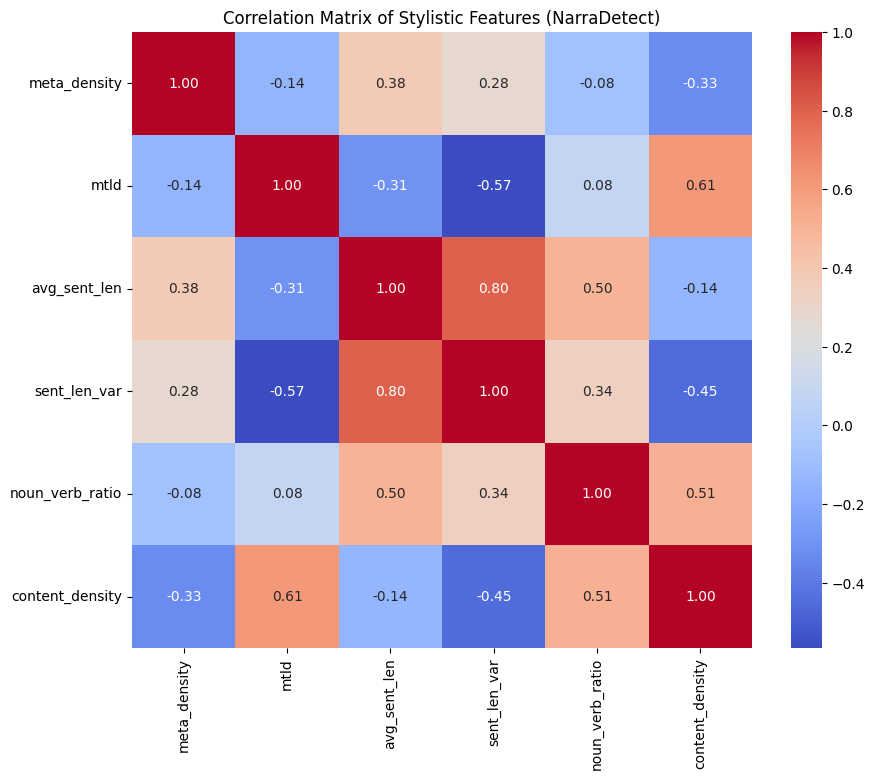

In [118]:
# plot correlation matrix
# Exclude 'document_name' and 'author' columns as they are not numeric for correlation calculation
corr_matrix = narradetect_stylistics.drop(columns=['document_name', 'author']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stylistic Features (NarraDetect)')
plt.show()

In [120]:
# Prepare data for clustering: Drop 'document_name', 'author', and highly correlated 'sent_len_var'
narradetect_features_df = narradetect_stylistics.drop(columns=['document_name', 'author', 'avg_sent_len'])

scaler_narradetect = StandardScaler()
scaled_narradetect_features = scaler_narradetect.fit_transform(narradetect_features_df)

print("NarraDetect features scaled and ready for clustering.")

NarraDetect features scaled and ready for clustering.


### Dendrogram for NarraDetect Hierarchical Clustering

NarraDetect Hierarchical Silhouette Score (k=4): 0.234


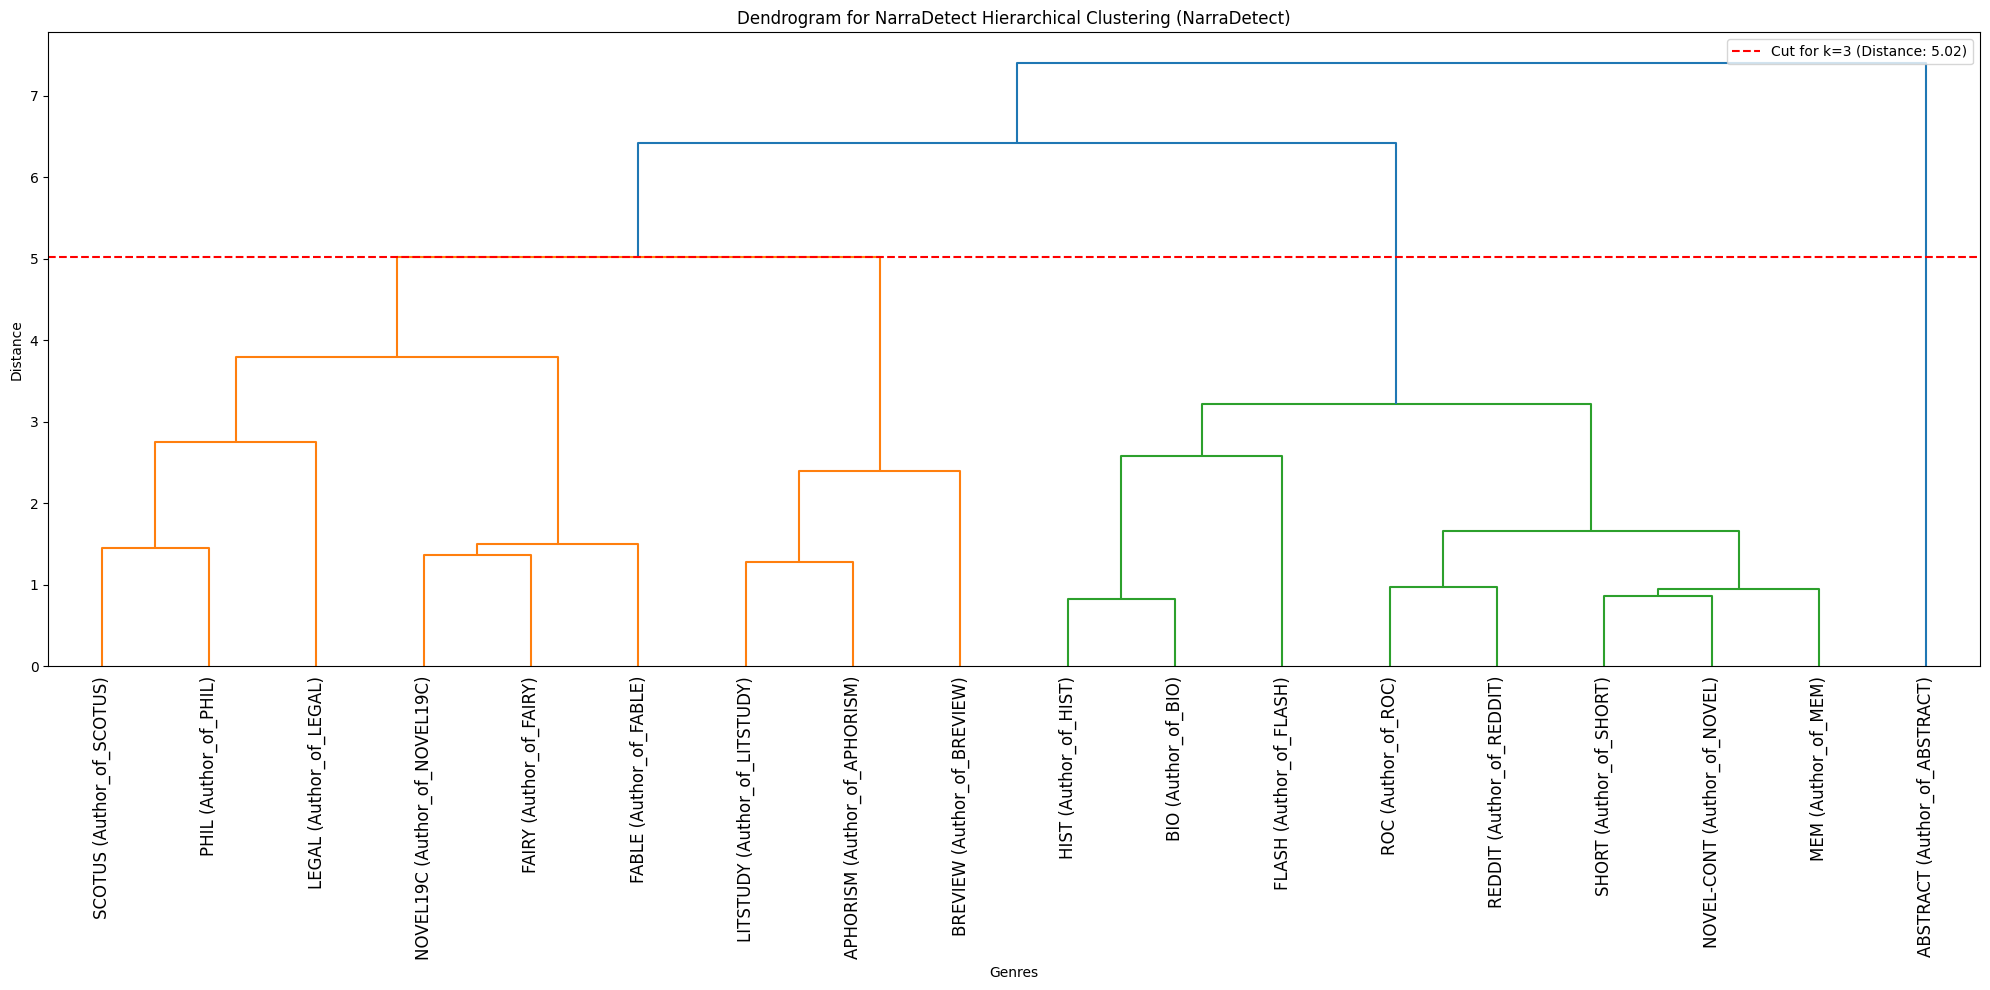

NarraDetect Hierarchical clustering complete and dendrogram displayed.


In [132]:
# Hierarchical Clustering for NarraDetect
hierarchical_narradetect = AgglomerativeClustering(n_clusters=3) # Using 3 clusters for comparison
hierarchical_narradetect_labels = hierarchical_narradetect.fit_predict(scaled_narradetect_features)
narradetect_stylistics['hierarchical_cluster'] = hierarchical_narradetect_labels

# Create narradetect_stylistics_with_author for dendrogram labels
narradetect_stylistics_with_genres = narradetect_stylistics.copy()
narradetect_stylistics_with_genres['full_label'] = narradetect_stylistics_with_genres['document_name'] + ' (' + narradetect_stylistics_with_genres['author'] + ')'

# Evaluate Hierarchical Clustering
narradetect_hierarchical_silhouette = silhouette_score(scaled_narradetect_features, hierarchical_narradetect_labels)
print(f"NarraDetect Hierarchical Silhouette Score (k=4): {narradetect_hierarchical_silhouette:.3f}")

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of labels
linked_narradetect = linkage(scaled_narradetect_features, method='ward') # 'ward' minimizes the variance of the clusters being merged
dendrogram(linked_narradetect,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False, # Set to False to prevent overlapping with custom labels
           labels=narradetect_stylistics_with_genres['full_label'].tolist())
plt.title('Dendrogram for NarraDetect Hierarchical Clustering (NarraDetect)')
plt.xlabel('Genres')
plt.ylabel('Distance')
plt.xticks(rotation=90) # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Add horizontal line for k=4 clusters
k_3_cut_height = linked_narradetect[len(linked_narradetect) - 3, 2]
plt.axhline(y=k_3_cut_height, color='r', linestyle='--', label=f'Cut for k=3 (Distance: {k_3_cut_height:.2f})')
plt.legend()

plt.show()

print("NarraDetect Hierarchical clustering complete and dendrogram displayed.")

In [122]:
narradetect_cluster_books = narradetect_stylistics_with_genres.groupby('hierarchical_cluster')['full_label'].apply(list).reset_index()
narradetect_cluster_books.columns = ['Hierarchical Cluster', 'Genres']
print(narradetect_cluster_books.to_string())
print("This table lists all books and their authors within each hierarchical cluster for NarraDetect.")

   Hierarchical Cluster                                                                                                                                                                                                                                                   Genres
0                     0  [APHORISM (Author_of_APHORISM), BREVIEW (Author_of_BREVIEW), FABLE (Author_of_FABLE), FAIRY (Author_of_FAIRY), LEGAL (Author_of_LEGAL), LITSTUDY (Author_of_LITSTUDY), NOVEL19C (Author_of_NOVEL19C), PHIL (Author_of_PHIL), SCOTUS (Author_of_SCOTUS)]
1                     1                                                                                                                                                                                                                          [ABSTRACT (Author_of_ABSTRACT)]
2                     2                                                        [BIO (Author_of_BIO), FLASH (Author_of_FLASH), HIST (Author_of_HIST), MEM (Author_of_MEM), NOVEL-CONT 

### NarraDetect Document Similarity Heatmap

This heatmap visualizes the pairwise stylistic similarity between individual documents within the NarraDetect dataset. Each cell's color represents the similarity score between two documents, providing insights into which genres or texts share similar stylistic profiles based on the extracted features.

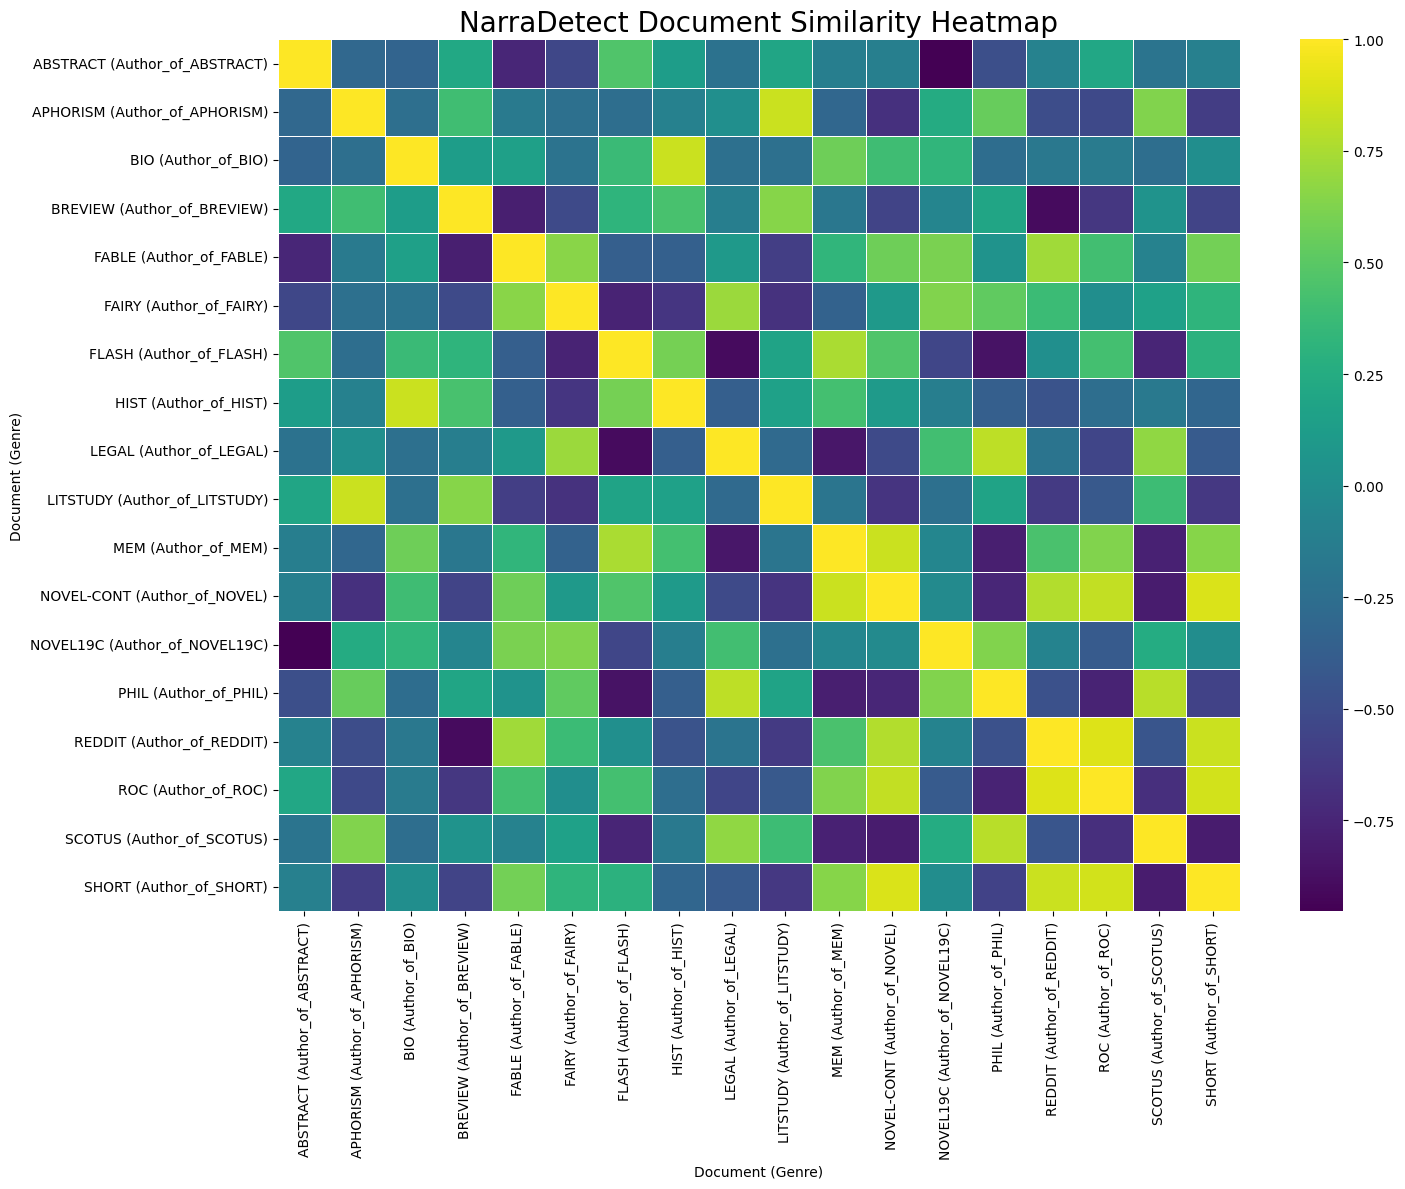

The heatmap above visualizes the pairwise stylistic similarity between NarraDetect documents. Darker colors indicate higher similarity, suggesting stylistic resemblances between different genres or texts.


In [123]:
# Calculate cosine similarity between NarraDetect documents
similarity_matrix_narradetect = cosine_similarity(scaled_narradetect_features)

# Add labels for each NarraDetect document
narradetect_labels = narradetect_stylistics_with_genres['full_label'].tolist()

# Convert the similarity matrix to a DataFrame for better labeling
similarity_df_narradetect = pd.DataFrame(similarity_matrix_narradetect, index=narradetect_labels, columns=narradetect_labels)

plt.figure(figsize=(15, 12)) # Adjust figure size for readability
sns.heatmap(similarity_df_narradetect,
            annot=False, # Set to True to show similarity values on the heatmap if desired
            cmap='viridis', # Choose a colormap
            fmt=".2f", # Format annotation values
            linewidths=.5) # Add lines between cells
plt.title('NarraDetect Document Similarity Heatmap', size=20)
plt.xlabel('Document (Genre)')
plt.ylabel('Document (Genre)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("The heatmap above visualizes the pairwise stylistic similarity between NarraDetect documents. Darker colors indicate higher similarity, suggesting stylistic resemblances between different genres or texts.")

### Feature Importance for NarraDetect Hierarchical Clustering

Similar to the Authors dataset, we will analyze feature importance for NarraDetect to identify which stylistic features are most influential in forming its hierarchical clusters.

,feature,importance
0,sent_len_var,0.306042
1,mtld,0.264742
2,noun_verb_ratio,0.166393
3,meta_density,0.142670
4,content_density,0.120153


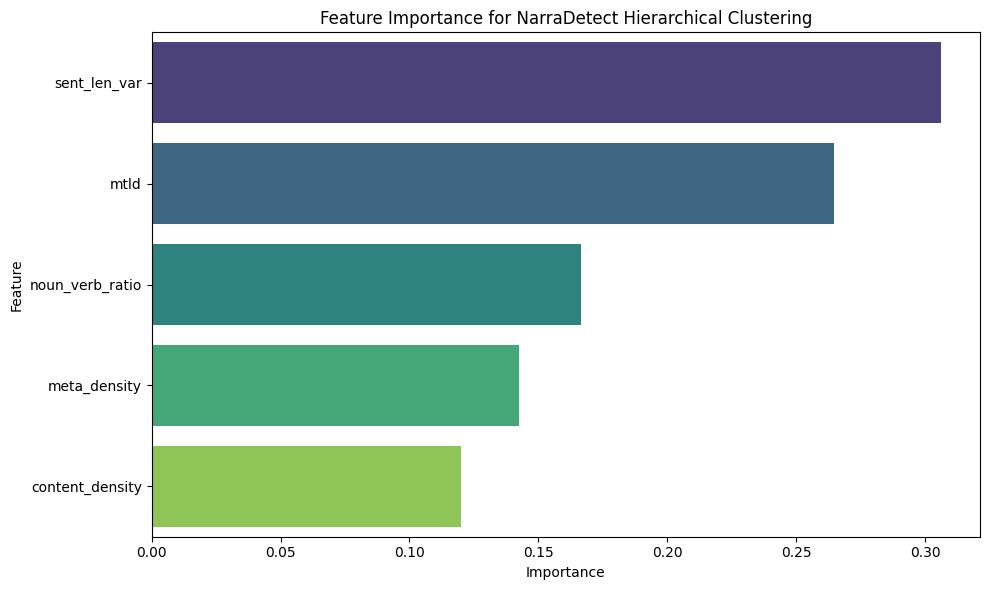

Feature importance analysis for NarraDetect complete. The plot and table above show which features were most influential in determining the hierarchical clusters.


In [124]:
# Prepare data for feature importance analysis for NarraDetect
X_narradetect = scaled_narradetect_features # Scaled features from narradetect_stylistics
y_narradetect = hierarchical_narradetect_labels # Hierarchical cluster labels for NarraDetect

# Train a RandomForestClassifier
rf_model_narradetect = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_model_narradetect.fit(X_narradetect, y_narradetect)

# Get feature importances
feature_importances_narradetect = rf_model_narradetect.feature_importances_

# Map importances to feature names
feature_names_narradetect = narradetect_features_df.columns
importance_df_narradetect = pd.DataFrame({'feature': feature_names_narradetect, 'importance': feature_importances_narradetect})
importance_df_narradetect = importance_df_narradetect.sort_values(by='importance', ascending=False).reset_index(drop=True)

display(importance_df_narradetect)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df_narradetect, palette='viridis')
plt.title('Feature Importance for NarraDetect Hierarchical Clustering')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("Feature importance analysis for NarraDetect complete. The plot and table above show which features were most influential in determining the hierarchical clusters.")

## Saving Stylistic Feature Datasets

### 1. Stylistic Features per Author

In [125]:
authors_stylistics_with_author.to_csv('stylistic_features_per_author.csv', index=False)
print("Saved 'stylistic_features_per_author.csv'")

Saved 'stylistic_features_per_author.csv'


### 2. Stylistic Features per Genre

In [126]:
narradetect_stylistics_with_genres.to_csv('stylistic_features_per_genre.csv', index=False)
print("Saved 'stylistic_features_per_genre.csv'")

Saved 'stylistic_features_per_genre.csv'


### 3. Mean Stylistic Features per Author Cluster

In [128]:
author_cluster_mean_features = authors_stylistics_with_author.groupby('hierarchical_cluster')[['meta_density', 'mtld', 'avg_sent_len', 'sent_len_var', 'noun_verb_ratio', 'content_density']].mean().reset_index()
author_cluster_mean_features.to_csv('mean_stylistic_features_per_author_cluster.csv', index=False)
print("Saved 'mean_stylistic_features_per_author_cluster.csv'")

Saved 'mean_stylistic_features_per_author_cluster.csv'


### 4. Mean Stylistic Features per NarraDetect Cluster

In [130]:
narradetect_features = narradetect_stylistics.drop(columns=['document_name', 'author', 'hierarchical_cluster']).columns.tolist()
narradetect_cluster_mean_features = narradetect_stylistics_with_genres.groupby('hierarchical_cluster')[narradetect_features].mean().reset_index()
narradetect_cluster_mean_features.to_csv('mean_stylistic_features_per_narradetect_cluster.csv', index=False)
print("Saved 'mean_stylistic_features_per_narradetect_cluster.csv'")

Saved 'mean_stylistic_features_per_narradetect_cluster.csv'


In [131]:
narradetect_cluster_mean_features.head()

,hierarchical_cluster,meta_density,mtld,avg_sent_len,sent_len_var,noun_verb_ratio,content_density
0,0,0.183499,138.011533,26.852626,425.931644,1.688790,0.438390
1,1,0.042255,228.527417,21.920561,120.426400,2.717842,0.557614
2,2,0.153588,192.857621,16.580110,150.752422,1.298276,0.449838


# Future work

### 1. Advanced Model Training: Hyperparameter Tuning and Cross-Validation

Instead of fixed training parameters, we can implement a more robust training strategy using hyperparameter tuning (e.g., with `Optuna` or `Ray Tune`) and k-fold cross-validation. This will lead to more reliable model performance estimates and potentially better-performing models.

(keeps crashing)

### 3. More Advanced Feature Engineering (Beyond Stylistic Features)

These might require more complex NLP pipelines but can capture deeper insights.

Examples include:
*   **Syntactic Features**: Dependency parse patterns related to metaphor (e.g., subject-verb-object relationships involving abstract/concrete words).
*   **Semantic Features**: Word embeddings (e.g., word2vec, GloVe, FastText) or contextual embeddings (from BERT, RoBERTa) to capture semantic similarity and distance between words. You could calculate vector differences between target words and their typical contexts.
*   **Discourse Features**: Features that capture how metaphors are used across sentences or within larger textual units.
*   **Lexical Semantic Resources**: Integrating knowledge from resources like WordNet (synonyms, hypernyms, hyponyms) or ConceptNet.



### 4. Incorporate Readability and Text Complexity Scores

To provide a more comprehensive measure of text complexity, we will integrate readability indices like **Flesch-Kincaid Grade Level** and **Flesch Reading Ease**. These scores consider factors such as sentence length and word complexity (e.g., number of syllables) to quantify how easy or difficult a text is to understand. Adding these features can help differentiate clusters based on the target audience or perceived textual difficulty, offering another crucial dimension to our stylistic analysis. We will use the `textstat` library for this.

### 4. Exploring Alternative Clustering Algorithms and Evaluating Cluster Quality

Beyond K-Means and Agglomerative, you could explore other clustering methods like DBSCAN (density-based spatial clustering of applications with noise), Spectral Clustering, or Gaussian Mixture Models. Each has different assumptions and might reveal different structures in your data. Also, use more metrics to evaluate cluster quality.
